In [26]:
import torch
import pyro
from chirho.observational.handlers import condition
from chirho.interventional.handlers import do
from chirho.counterfactual.handlers import MultiWorldCounterfactual
import pyro.distributions as dist
from pyro.ops.indexing import Vindex
from pyro.poutine import block
from pyro.infer import SVI
from pyro.infer.autoguide import AutoNormal

## Deterministic case

In [2]:
def print_sites(tr):
    for key in tr.trace.nodes.keys():
        print(f"{key}: {tr.trace.nodes[key]["value"]}")

In [3]:
def obcb1():

    gender = pyro.sample("gender", dist.Bernoulli(torch.tensor(0.5))) #1 is male
    credit_sufficient = pyro.sample("credit_sufficient", dist.Bernoulli(torch.tensor(0.5)))

    credit_check = pyro.deterministic("credit_check", gender)
    credit_deemed_insufficient = pyro.deterministic(
        "credit_deemed_insufficient",
        credit_check * (1 - credit_sufficient)
    )

    loan = pyro.deterministic(
        "loan",
        (1- credit_deemed_insufficient) * gender
    )

    return loan

In [4]:
# example 1 Bob applied and was denied, because his score was low

bob = {
    "gender": torch.tensor(1.),
    "credit_sufficient": torch.tensor(0.)
}

with condition(data = bob):
    result = obcb1()

print(result)
assert result == torch.tensor(0.)

tensor(0.)


In [5]:
# if credit sufficient, the result would be different
with do(actions = {"credit_sufficient": torch.tensor(1.),}):
    with condition(data = bob):
      with pyro.poutine.trace() as tr:
          result = obcb1()

print_sites(tr)

assert result == torch.tensor(1.)

gender: 1.0
credit_sufficient: 1.0
credit_check: 1.0
credit_deemed_insufficient: 0.0
loan: 1.0


In [6]:
# had his gender been different he still wouldn't have received the loan

with do(actions = {"gender": torch.tensor(0.),}):
    with condition(data = bob):
      with pyro.poutine.trace() as tr:
          result = obcb1()

print_sites(tr)

assert result == torch.tensor(0.)

gender: 0.0
credit_sufficient: 0.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0


In [7]:
alice = {
    "credit_sufficient": torch.tensor(0.),
    "gender": torch.tensor(0.)
}

# Alice gets denied

with condition(data = alice):
    with pyro.poutine.trace() as tr:
      result = obcb1()

print_sites(tr)
assert result == torch.tensor(0.)

gender: 0.0
credit_sufficient: 0.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0


In [8]:
# but-for for gender: doesn't change the outcome

with do(actions = {"gender": torch.tensor(1.)}):
    with condition(data = alice):
        with pyro.poutine.trace() as tr:
            result = obcb1()

print_sites(tr)
assert result == torch.tensor(0.)

gender: 1.0
credit_sufficient: 0.0
credit_check: 1.0
credit_deemed_insufficient: 1.0
loan: 0.0


In [9]:
#but-for for credit_sufficient: doesn't change the outcome

with do(actions = {"credit_sufficient": torch.tensor(1.)}):
    with condition(data = alice):
        with pyro.poutine.trace() as tr:
            result = obcb1()

print_sites(tr)
assert result == torch.tensor(0.)

gender: 0.0
credit_sufficient: 1.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0


In [10]:
# but=for for sets changing both changes the outcome 

with do(actions = {"credit_sufficient": torch.tensor(1.),
                    "gender": torch.tensor(1.)}):
    with condition(data = alice):
        with pyro.poutine.trace() as tr:
            result = obcb1()

print_sites(tr)
assert result == torch.tensor(1.)

gender: 1.0
credit_sufficient: 1.0
credit_check: 1.0
credit_deemed_insufficient: 0.0
loan: 1.0


In [11]:
# now fix mediator, credit deemed insufficient

# first, factual run

with condition(data = alice):
    with pyro.poutine.trace() as tr_factual:
        result = obcb1()

credit_deemed_insufficient = {"credit_deemed_insufficient":
             tr_factual.trace.nodes['credit_deemed_insufficient']['value']
}

credit_check =  {"credit_check":
             tr_factual.trace.nodes['credit_check']['value']
}
# 


In [12]:
tr_factual.trace.nodes.keys()

all_witnesses = [
 credit_check, credit_deemed_insufficient, credit_check | credit_deemed_insufficient
]

In [13]:
# now intervene both with witness and alternative value for gender

with do(actions =    {"gender": torch.tensor(1.)}):
    with do(actions = credit_deemed_insufficient):
        with condition(data = alice):
            with pyro.poutine.trace() as tr_witness_gender:
                result = obcb1()

print_sites(tr_witness_gender)

# outome changes
assert result == torch.tensor(1.)

gender: 1.0
credit_sufficient: 0.0
credit_check: 1.0
credit_deemed_insufficient: 0.0
loan: 1.0


In [14]:
# compare with holding witness and intervening on credit sufficient
# no change, no matter which witness set we take

for witness in all_witnesses:
    with do(actions =  {"credit_sufficient": torch.tensor(1.)}):
        with do(actions = witness):
            with condition(data = alice):
                with pyro.poutine.trace() as tr_witness_credit:
                    result = obcb1()

    print_sites(tr_witness_credit)

    assert result == torch.tensor(0.)

gender: 0.0
credit_sufficient: 1.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0
gender: 0.0
credit_sufficient: 1.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0
gender: 0.0
credit_sufficient: 1.0
credit_check: 0.0
credit_deemed_insufficient: 0.0
loan: 0.0


## Stochastic case

### The model

   The bank  proceeds with credit score checks for a randomly selected 20\% of women,
    and does not perform credit checks for a randomly selected 10\% of men.
     Unchecked applicants are rejected.
    Furthermore, if a man's credit check fails, he is nevertheless accepted 5\% of the time;
    if a woman's credit check succeeds, she is denied 10\% of the time. \label{ex:obcb_stochastic}


In [15]:
prob_loan  = torch.zeros(2,2)
# 0th dim gender
# 1st dim whether deemed

# woman deemed, probability of success 0
prob_loan[0, 1] = 0.
# woman not deemed, probability of success .9
prob_loan[0, 0] = 0.9

# man deemed, probability of success 5%
prob_loan[1, 1] = 0.05
# man not deemed,  probability of success 1
prob_loan[1, 0] = 1

print(prob_loan)
# 

#smokes_prob = Vindex(smokes_cond_prob)[..., stress.int()]

tensor([[0.9000, 0.0000],
        [1.0000, 0.0500]])


In [16]:
def obcb_stochastic():

    gender = pyro.sample("gender", dist.Bernoulli(torch.tensor(0.5))) #1 is male
    credit_sufficient = pyro.sample("credit_sufficient", dist.Bernoulli(torch.tensor(0.5)))

    prob_of_credit_check = pyro.deterministic("prob_of_credit_check",
        (1-gender) * torch.tensor(0.2) + gender * torch.tensor(0.9)
    )

    credit_check = pyro.sample("credit_check", dist.Bernoulli(prob_of_credit_check))
    
    credit_deemed_insufficient = pyro.deterministic(
        "credit_deemed_insufficient",
        credit_check * (1 - credit_sufficient)
    )

    prob_success  = pyro.deterministic("prob_success", 
                            Vindex(prob_loan)[..., gender.int(),
                                 credit_deemed_insufficient.int()]
    )

    _loan = pyro.sample("_loan", dist.Bernoulli(prob_success))
    loan = pyro.deterministic("loan", _loan * credit_check)


    return loan


### Probability of necessity

In [17]:
# Bob runs factual

# analytically
# His probability of getting a loan is $0.9 \times 0.05 = 0.045$. 
# 
# If he were female, this chance would decrease to $0.2 \times 0=0$.
 


with condition(data = bob):
    with pyro.plate("sample", size = 1e6):
        with pyro.poutine.trace() as tr:
            obcb_stochastic()

pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Bob getting a loan is {pr_loan}")


with do(actions = {"gender": torch.tensor(0.)}):
    with condition(data = bob):
        with pyro.plate("sample", size = 1e6):
            with pyro.poutine.trace() as tr:
                obcb_stochastic()

    pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Bob getting a loan  if he was a woman is {pr_loan}")


with do(actions = {"credit_sufficient": torch.tensor(1.)}):
    with condition(data = bob):
        with pyro.plate("sample", size = 1e6):
            with pyro.poutine.trace() as tr:
                obcb_stochastic()

    pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Bob getting a loan if he ad good score is {pr_loan}")



Probability of Bob getting a loan is 0.044934000819921494
Probability of Bob getting a loan  if he was a woman is 0.0
Probability of Bob getting a loan if he ad good score is 0.8999649882316589


In [18]:
# Alice necessity



with condition(data = alice):
    with pyro.plate("sample", size = 1e6):
        with pyro.poutine.trace() as tr:
            obcb_stochastic()

pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Alice getting a loan is {pr_loan}")


with do(actions = {"gender": torch.tensor(1.)}):
    with condition(data = alice):
        with pyro.plate("sample", size = 1e6):
            with pyro.poutine.trace() as tr:
                obcb_stochastic()

    pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Alice getting a loan if she was male is {pr_loan}")


with do(actions = {"credit_sufficient": torch.tensor(1.)}):
    with condition(data = alice):
        with pyro.plate("sample", size = 1e6):
            with pyro.poutine.trace() as tr:
                obcb_stochastic()

    pr_loan = tr.trace.nodes['loan']['value'].mean()

print(f"Probability of Alice getting a loan if she had good score is {pr_loan}")



Probability of Alice getting a loan is 0.0
Probability of Alice getting a loan if she was male is 0.045003000646829605
Probability of Alice getting a loan if she had good score is 0.18018700182437897


In [19]:
print(alice)

{'credit_sufficient': tensor(0.), 'gender': tensor(0.)}


### Probability of sufficiency

In [20]:
# sufficiency. for gender, effectively, just check prob of female with insufficient credit failing


with condition(data = alice):
    with pyro.plate("sample", size = 1e6):
        with pyro.poutine.trace() as tr:
            obcb_stochastic()

print(f"Probability of Alice failing now is {1 - tr.trace.nodes['loan']['value'].mean()}")

Probability of Alice failing now is 1.0


In [21]:
tr.trace.nodes.keys()

odict_keys(['gender', 'credit_sufficient', 'prob_of_credit_check', 'credit_check', 'credit_deemed_insufficient', 'prob_success', '_loan', 'loan'])

In [22]:
# now condition on her being a female ($F=f$) with 
# sufficient credit ($c'$) and succeeding ($y'$). 
# Quick mental inference tells us that both 
# \texttt{credit check} 
# and  \texttt{loan if checked}  must have had value 1.
#  Given this setup we now intervene on her credit 
# to be insufficient and evaluate the probability of
#  her failing.

alice_suff_credit = {
    "gender": torch.tensor(0.),
    "credit sufficient": torch.tensor(1.),
    "credit_check": torch.tensor(1.),
    "load_if_checked": torch.tensor(1.)
}

with do(actions = {
        "credit_sufficient": torch.tensor(0.)
}):
    with condition(data = alice_suff_credit):
        with pyro.plate("sample", size = 1e6):
            with pyro.poutine.trace() as tr:
                obcb_stochastic()

print(f"Probability of Alice failing now is {1 - tr.trace.nodes['loan']['value'].mean()}")


Probability of Alice failing now is 1.0


In [27]:
tr.trace.nodes.keys()

odict_keys(['gender', 'credit_sufficient', 'prob_of_credit_check', 'credit_check', 'credit_deemed_insufficient', 'prob_success', '_loan', 'loan'])

In [ ]:
#For Bob's \texttt{credit sufficient}, we need to condition on
#him being male ($F=f$), his credit being sufficient ($c'$) and
#him succeding ($y'$). Then we intervene making his credit isufficient
#  and ask for the probability of him failing.

bob_suff_credit = {
    "gender": torch.tensor(1.),
    "credit sufficient": torch.tensor(1.),
    "loan": torch.tensor(1.)
}


[iteration 0001] loss: 1.5429


/home/rafal/miniconda3/envs/roc/lib/python3.13/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'credit_check', '_loan', 'credit_sufficient'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


#### Probability and sufficiency

In [23]:
# necessity and sufficiency for Bob

suff_nec_gender = {
    "gender": (torch.tensor(0.), torch.tensor(1.))
}

suff_nec_credit  = {
    "credit_sufficient": (torch.tensor(0.), torch.tensor(1.))
}

with MultiWorldCounterfactual() as mwc_gender_bob:
    with do(actions = suff_nec_gender):
        with condition(data = bob):
            with pyro.plate("sample", size = 1e6):
                with pyro.poutine.trace() as tr_nec_suff_gender_bob:
                    obcb_stochastic()

with MultiWorldCounterfactual() as mwc_credit_bob:
    with do(actions = suff_nec_credit):
        with condition(data = bob):
            with pyro.plate("sample", size = 1e6):
                with pyro.poutine.trace() as tr_nec_suff_credit_bob:
                    obcb_stochastic()



In [24]:
print(bob)

{'gender': tensor(1.), 'credit_sufficient': tensor(0.)}


Prob nec suff for bob gender is 0.0


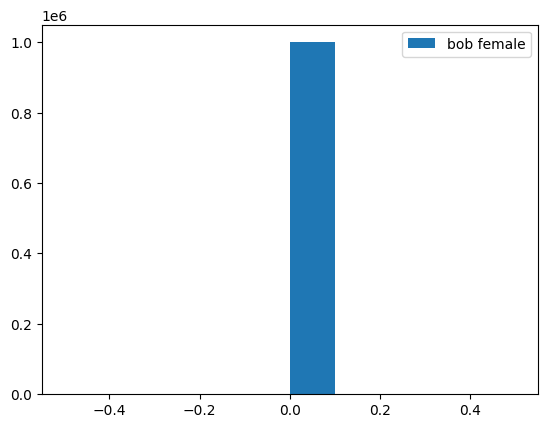

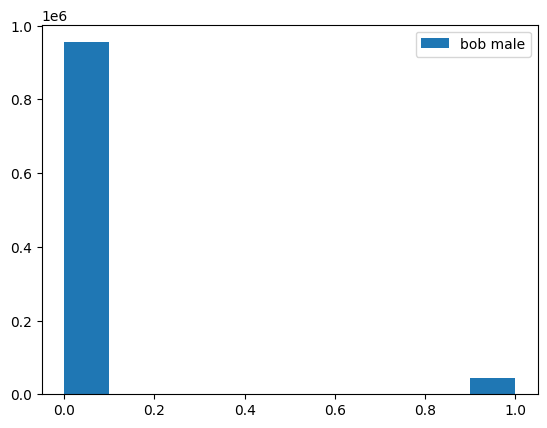

In [25]:
loan_bob_gender = tr_nec_suff_gender_bob.trace.nodes['loan']['value']

loan_bob_female = loan_bob_gender[1,...].flatten()
loan_bob_male = loan_bob_gender[2,...].flatten()


# actual values: Bob is male with insufficient credit, fails 

# necessity world: bob is female with insufficient credit,
# and we ask about the probability of him succeeding

# sufficiency world: bob is male with insufficient credit
# and we ask about the probability of him failing



bob_gender_joint_outcome =loan_bob_female * (1-loan_bob_male)

prob_suff_nec_bob_gender = bob_gender_joint_outcome.mean()

print(f"Prob nec suff for bob gender is {prob_suff_nec_bob_gender.mean()}")


import matplotlib.pyplot as plt
plt.hist(loan_bob_female, label = "bob female")
plt.legend()
plt.show()

plt.hist(loan_bob_male, label = "bob male")
plt.legend()
plt.legend()

# the prob of succeeding if female while still low credit is 0


Prob nec suff for bob credit is 0.8549100160598755


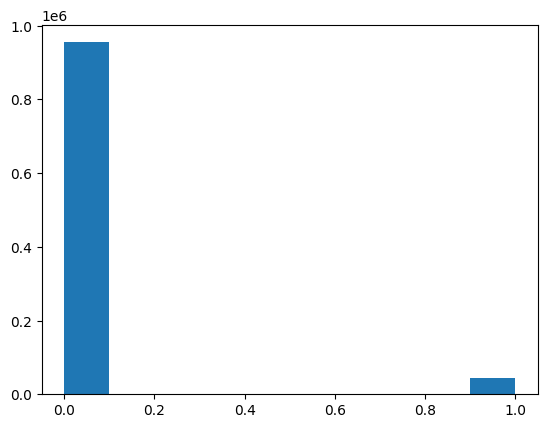

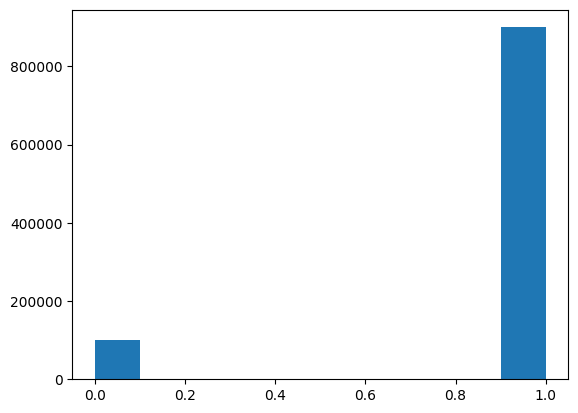

In [26]:
# (a) in the necessity world,
#   we make his credit sufficient and track whether he succeeds, 
#   (b) in the sufficiency world, we make his credit still insufficient and 
#   track whether he still fails.


loan_bob_credit = tr_nec_suff_credit_bob.trace.nodes['loan']['value']

loan_bob_low_credit = loan_bob_credit[1,...].flatten()
loan_bob_high_credit = loan_bob_credit[2,...].flatten()


bob_credit_joint_outcome = (1-loan_bob_low_credit) * loan_bob_high_credit

prob_suff_nec_bob_credit = bob_credit_joint_outcome.mean()

print(f"Prob nec suff for bob credit is {prob_suff_nec_bob_credit}")

plt.hist(loan_bob_low_credit)
plt.show()

plt.hist(loan_bob_high_credit)
plt.show()


In [30]:

with MultiWorldCounterfactual():
    with do(actions = suff_nec_gender):
        with condition(data = alice):
            with pyro.plate("sample", size = 1e6):
                with pyro.poutine.trace() as tr_nec_suff_gender_alice:
                    obcb_stochastic()

with MultiWorldCounterfactual():
    with do(actions = suff_nec_credit):
        with condition(data = alice):
            with pyro.plate("sample", size = 1e6):
                with pyro.poutine.trace() as tr_nec_suff_credit_alice:
                    obcb_stochastic()


Prob nec suff for alice gender is 0.18026000261306763


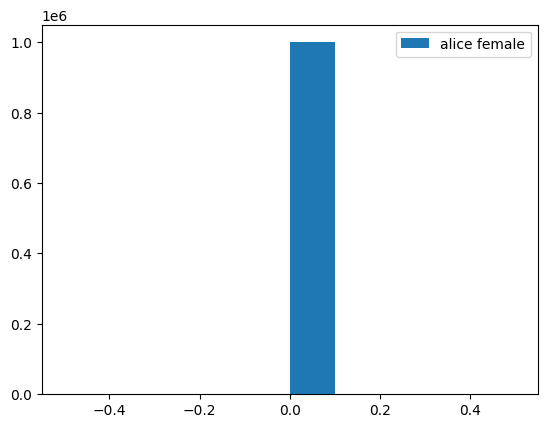

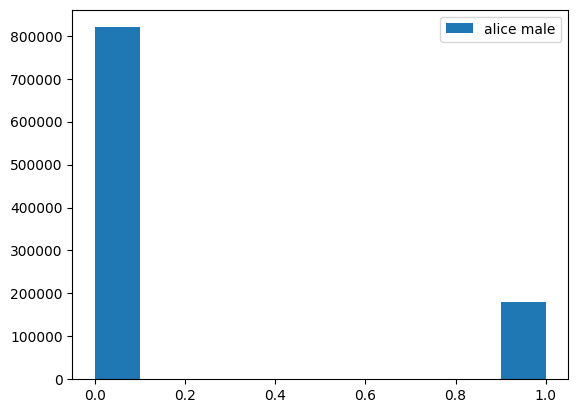

In [35]:
loan_alice_gender = tr_nec_suff_credit_alice.trace.nodes['loan']['value']

loan_alice_female = loan_alice_gender[1,...].flatten()
loan_alice_male = loan_alice_gender[2,...].flatten()


#   (3) For Alice, \texttt{gender} (female with insufficient credit, fails). 
#   (a) in the sufficiency world we make her still female and look at failure, 
#   (b) in the necessity world we make her male and look at success.

alice_gender_joint_outcome =(1-loan_alice_female )* loan_alice_male

prob_suff_nec_alice_gender = alice_gender_joint_outcome.mean()

print(f"Prob nec suff for alice gender is {prob_suff_nec_alice_gender.mean()}")


import matplotlib.pyplot as plt
plt.hist(loan_alice_female, label = "alice female")
plt.legend()
plt.show()

plt.hist(loan_alice_male, label = "alice male")
plt.legend()
plt.legend()

# the prob of succeeding if female while still low credit is 0


Prob nec suff for alice gender is 0.04494199901819229


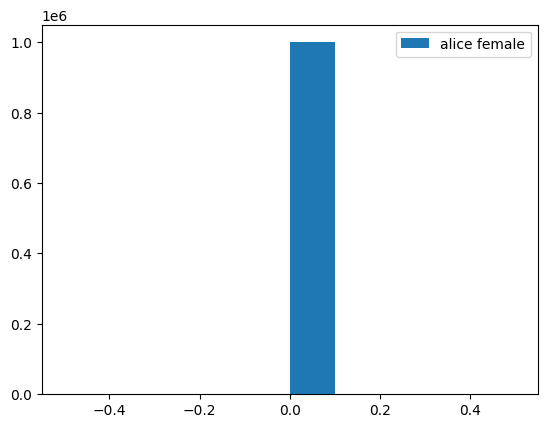

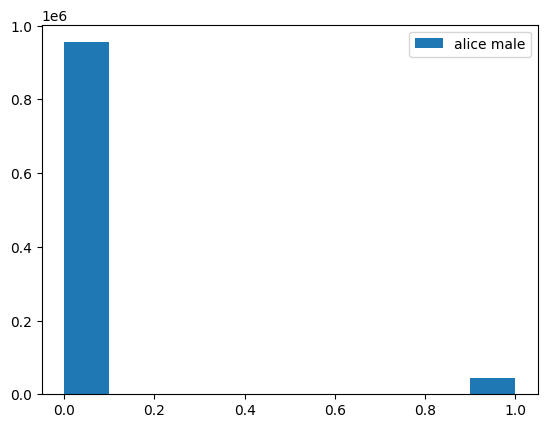

In [33]:
loan_alice_credit = tr_nec_suff_credit_alice.trace.nodes['loan']['value']

loan_alice_credit_low = loan_alice_credit[1,...].flatten()
loan_alice_credit_high = loan_alice_credit[2,...].flatten()

#   (4) For Alice, \texttt{credit sufficient}, (a) in the sufficiency world we set it to be
#   still insufficient and look at failures, and (b) in the necessity world we set 
#   her credit to be sufficient and look at success.

alice_credit_joint_outcome =(1-loan_alice_credit_low )* loan_alice_male

prob_suff_nec_alice_credit = alice_credit_joint_outcome.mean()

print(f"Prob nec suff for alice gender is {prob_suff_nec_alice_credit.mean()}")


import matplotlib.pyplot as plt
plt.hist(loan_bob_female, label = "alice female")
plt.legend()
plt.show()

plt.hist(loan_bob_male, label = "alice male")
plt.legend()
plt.legend()

# the prob of succeeding if female while still low credit is 0

